# LENDING CLUB

# ANÁLISE EXPLORATÓRIA DE DADOS

# 1. IMPORTANDO BIBLIOTECAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

# 2. CONJUNTO DE DADOS

In [2]:
# Carrega o dataframe limpo, salvo ao fim do notebook 01
df = pd.read_parquet('dados/loan_data_preprocessado.parquet')

print(f'Linhas: {df.shape[0]:,}')
print(f'Colunas: {df.shape[1]}')
df.head()

Linhas: 241,712
Colunas: 35


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,mths_since_earliest_cr_line,default,mths_since_last_delinq_missing,tot_coll_amt_missing,tot_cur_bal_missing,total_rev_hi_lim_missing
94,4000,4000,36,7.4300,124.3100,A,A2,0,RENT,40000.0000,Not Verified,2007-08-01,educational,NJ,3.4500,0.0000,0.0000,0.0000,2.0000,0.0000,330,11.0000,4.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,181,1,0,1,1,1
96,2000,2000,36,8.7000,63.3200,B,B1,0,RENT,70000.0000,Not Verified,2007-08-01,credit_card,NY,6.0700,0.0000,1.0000,24.0000,13.0000,0.0000,5967,19.8000,17.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,208,1,0,1,1,1
109,4000,4000,36,10.9100,130.7900,C,C3,1,RENT,18000.0000,Not Verified,2007-08-01,car,VA,18.0000,0.0000,1.0000,0.0000,4.0000,0.0000,5533,79.6000,5.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,196,1,0,1,1,1
110,15000,15000,36,12.1700,499.4500,D,D2,1,MORTGAGE,83200.0000,Not Verified,2007-08-01,credit_card,WI,17.0200,0.0000,5.0000,73.0000,14.0000,0.0000,37570,59.5000,37.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,266,1,0,1,1,1
111,3000,3000,36,7.7500,93.6700,A,A3,9,OWN,50000.0000,Not Verified,2007-08-01,vacation,WA,5.3500,0.0000,0.0000,0.0000,17.0000,0.0000,21050,0.7000,29.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,399,1,0,1,1,1


In [3]:
# Sanidade: o dataframe deve vir sem ausentes (tratados no notebook 01)
print(f'Total de ausentes: {df.isna().sum().sum()}')

Total de ausentes: 0


# 3. TAXA DE DEFAULT

Antes de explorar as variáveis, observamos a distribuição da variável-alvo. A proporção de inadimplentes define o grau de desbalanceamento da base e dimensiona o problema que o modelo busca resolver.

                  quantidade  percentual
Inadimplente (0)       50887     21.0500
Adimplente (1)        190825     78.9500


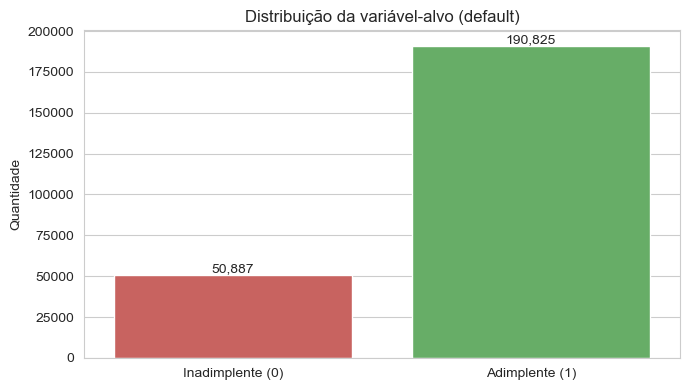

In [4]:
# Distribuição do alvo (lembrando: 1 = adimplente, 0 = inadimplente)
contagem = df['default'].value_counts().sort_index()
proporcao = df['default'].value_counts(normalize=True).sort_index() * 100

resumo = pd.DataFrame({
    'quantidade': contagem,
    'percentual': proporcao.round(2)
})
resumo.index = ['Inadimplente (0)', 'Adimplente (1)']
print(resumo)

# Gráfico
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='default', data=df, palette=['#d9534f', '#5cb85c'])
ax.set_xticklabels(['Inadimplente (0)', 'Adimplente (1)'])
ax.set_xlabel('')
ax.set_ylabel('Quantidade')
ax.set_title('Distribuição da variável-alvo (default)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

A base apresenta cerca de **21% de inadimplência**, um desbalanceamento moderado que precisará ser considerado na modelagem. Vale notar que essa taxa é superior à observada em estudos que mantêm os contratos em andamento (`Current`) na base: como esses contratos foram descartados no pré-processamento (por não terem desfecho conhecido), a taxa aqui reflete apenas empréstimos encerrados, resultando em uma medida mais fiel do risco realizado. Esse nível de inadimplência evidencia que há espaço para uma política de concessão mais seletiva, o que motiva o presente projeto.

# 4. VARIÁVEIS NUMÉRICAS

Analisamos a distribuição das variáveis numéricas para entender suas escalas, assimetrias e a presença de valores extremos.

In [5]:
# Seleciona variáveis numéricas para análise (exclui alvo, flags e datas)
excluir = ['default', 'issue_d',
           'mths_since_last_delinq_missing', 'tot_coll_amt_missing',
           'tot_cur_bal_missing', 'total_rev_hi_lim_missing']

num_features = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in excluir]

print(f'{len(num_features)} variáveis numéricas:')
print(num_features)

22 variáveis numéricas:
['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'mths_since_earliest_cr_line']


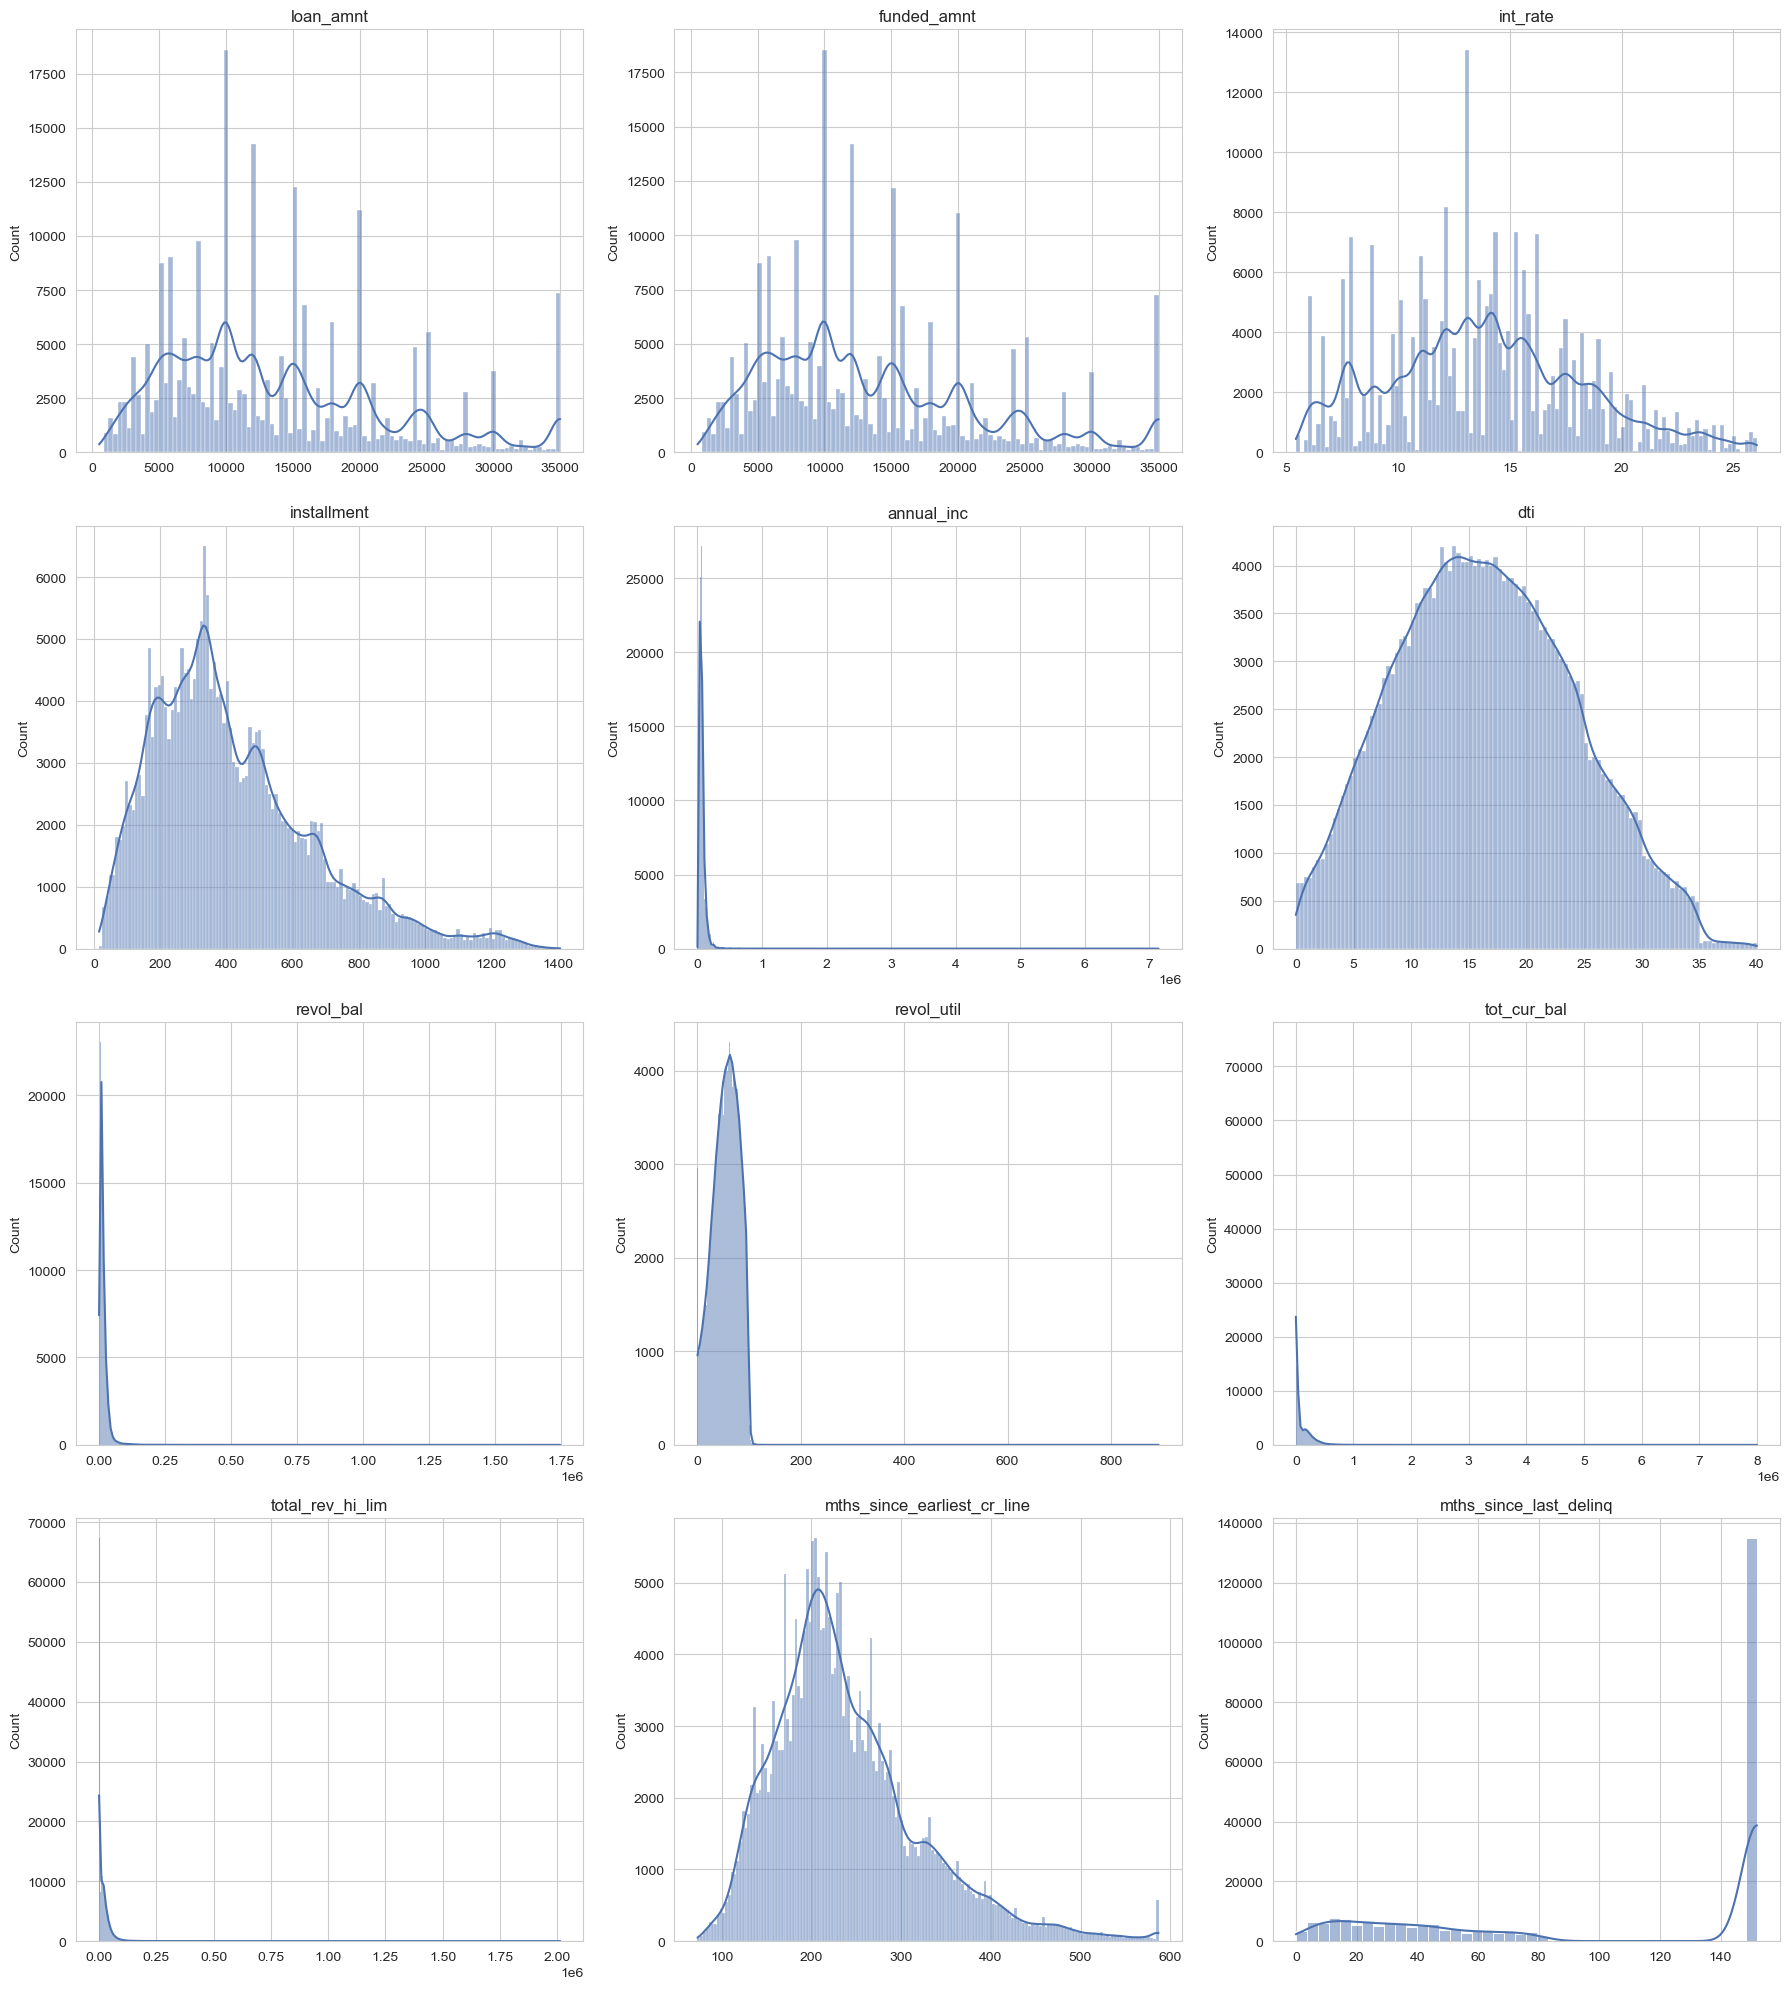

In [6]:
# Grupo A: variáveis contínuas — grid de histogramas
continuas = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment',
             'annual_inc', 'dti', 'revol_bal', 'revol_util',
             'tot_cur_bal', 'total_rev_hi_lim',
             'mths_since_earliest_cr_line', 'mths_since_last_delinq']

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
for ax, col in zip(axes.flat, continuas):
    sns.histplot(df[col], kde=True, ax=ax, color='#4c72b0')
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

As variáveis contínuas apresentam padrões típicos de dados financeiros. `loan_amnt` e `funded_amnt` têm distribuições praticamente idênticas, indicando forte redundância entre elas. Variáveis monetárias como `annual_inc`, `revol_bal` e `tot_cur_bal` exibem forte assimetria à direita, com cauda longa causada por poucos valores muito elevados. A variável `mths_since_last_delinq` apresenta uma concentração acentuada em seu valor máximo, resultante do preenchimento aplicado aos tomadores sem histórico de inadimplência; a informação sobre essa ausência foi preservada na variável indicadora correspondente. A assimetria observada não exige transformação prévia, pois a discretização por WoE, aplicada na etapa de modelagem, acomoda naturalmente esse tipo de distribuição.

In [7]:
# Grupo B: contagens discretas — estatística e proporção de zeros
contagens = ['delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
             'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq',
             'tot_coll_amt']

resumo_contagens = df[contagens].describe().T
resumo_contagens['pct_zeros'] = [(df[c] == 0).mean() * 100 for c in contagens]
resumo_contagens[['mean', 'std', 'min', '50%', 'max', 'pct_zeros']].round(2)

,mean,std,min,50%,max,pct_zeros
delinq_2yrs,0.2500,0.7400,0.0000,0.0000,29.0000,83.8700
inq_last_6mths,0.9100,1.1700,0.0000,1.0000,33.0000,47.8800
open_acc,10.8800,4.8300,1.0000,10.0000,76.0000,0.0000
pub_rec,0.1400,0.4200,0.0000,0.0000,11.0000,88.3700
total_acc,24.8300,11.6700,1.0000,23.0000,150.0000,0.0000
collections_12_mths_ex_med,0.0100,0.0800,0.0000,0.0000,6.0000,99.4400
acc_now_delinq,0.0000,0.0600,0.0000,0.0000,5.0000,99.7300
tot_coll_amt,145.8800,18669.0300,0.0000,0.0000,9152545.0000,91.8000


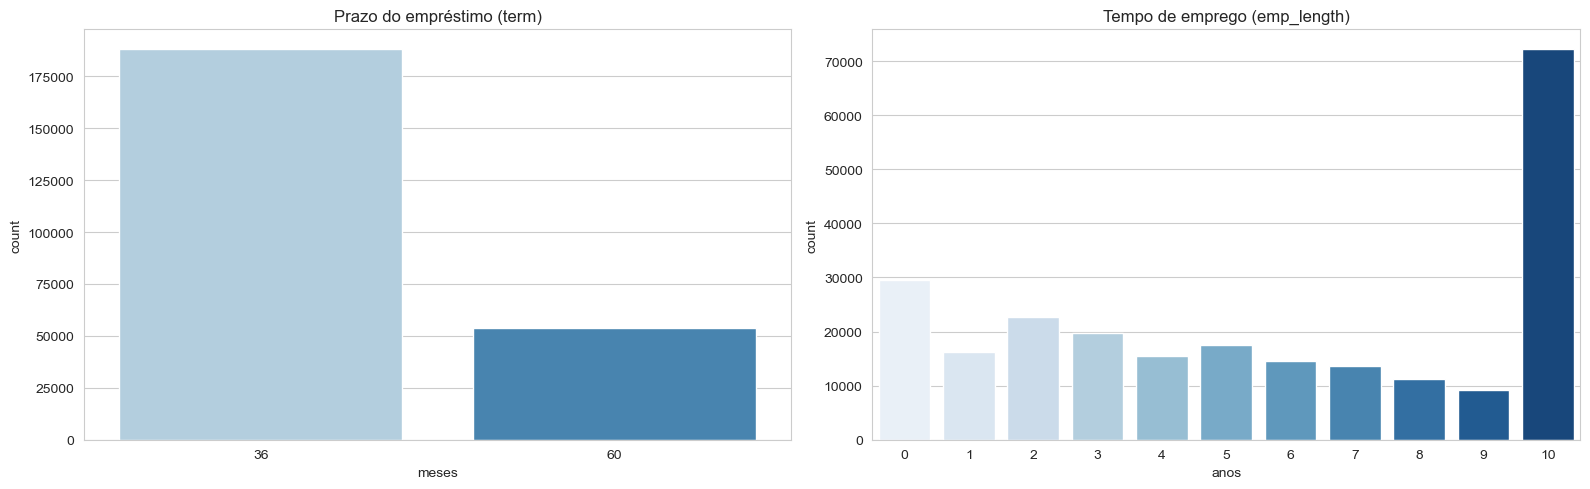

In [8]:
# Grupo C: term e emp_length — countplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(x='term', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Prazo do empréstimo (term)')
axes[0].set_xlabel('meses')

sns.countplot(x='emp_length', data=df, ax=axes[1], palette='Blues')
axes[1].set_title('Tempo de emprego (emp_length)')
axes[1].set_xlabel('anos')

plt.tight_layout()
plt.show()

Entre as variáveis de contagem, três apresentam baixíssima variância: `collections_12_mths_ex_med` (99,4% de zeros), `acc_now_delinq` (99,7%) e `tot_coll_amt` (91,8% de zeros, com outliers extremos). Por serem quase constantes, tendem a ter baixo poder discriminatório e serão reavaliadas para possível remoção na etapa de modelagem. As demais contagens (`delinq_2yrs`, `pub_rec`, `inq_last_6mths`, `open_acc`, `total_acc`) apresentam variabilidade adequada. Quanto às variáveis do Grupo C, predomina o prazo de 36 meses (cerca de 78% dos contratos), e `emp_length` concentra-se em "10+ anos", faixa que agrupa todos os tomadores com dez ou mais anos de emprego.

### Investigação de valores extremos

Algumas variáveis monetárias apresentaram valores muito elevados na cauda. Investigamos esses casos para verificar se representam erros de registro ou valores legítimos, o que define se devem ou não ser tratados.

In [9]:
# Investigação dos valores extremos nas variáveis monetárias
print('--- annual_inc > 3 milhões ---')
display(df.loc[df['annual_inc'] > 3e6, ['annual_inc', 'loan_amnt', 'dti', 'default']])

print('--- total_rev_hi_lim > 2 milhões ---')
display(df.loc[df['total_rev_hi_lim'] > 2e6, ['total_rev_hi_lim', 'annual_inc', 'loan_amnt', 'default']])

print('--- revol_bal > 1.5 milhões ---')
display(df.loc[df['revol_bal'] > 1.5e6, ['revol_bal', 'annual_inc', 'total_rev_hi_lim', 'default']])

--- annual_inc > 3 milhões ---


,annual_inc,loan_amnt,dti,default
12133,6000000.0000,5000,0.0100,1
13164,3900000.0000,25000,0.2000,1
90887,5000000.0000,35000,2.3600,1
92041,7141778.0000,14825,0.2500,1
106598,6100000.0000,30000,0.2200,1
385648,4900000.0000,15600,0.1100,1


--- total_rev_hi_lim > 2 milhões ---


,total_rev_hi_lim,annual_inc,loan_amnt,default
100440,2013133.0000,400000.0000,35000,1


--- revol_bal > 1.5 milhões ---


,revol_bal,annual_inc,total_rev_hi_lim,default
100440,1743266,400000.0000,2013133.0000,1
206638,1746716,400000.0000,1998700.0000,0


Os valores extremos correspondem a um número muito pequeno de tomadores (menos de dez no total) e apresentam atributos internamente coerentes, com renda, limite de crédito e valores de empréstimo compatíveis entre si. Não se trata de erros de registro, mas de tomadores de altíssima renda, legítimos na base. Por isso, esses valores são mantidos; a discretização por WoE, na etapa de modelagem, os alocará nas faixas superiores sem que distorçam o modelo.

# 5. VARIÁVEIS CATEGÓRICAS

Analisamos as variáveis categóricas, começando pela cardinalidade (número de categorias distintas), que orienta tanto a visualização quanto o agrupamento de categorias na etapa de modelagem.

In [10]:
# Cardinalidade das variáveis categóricas
cat_features = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

for col in cat_features:
    print(f'{col}: {df[col].nunique()} categorias')
    print(f'  {sorted(df[col].unique().tolist())}')
    print('-' * 80)

grade: 7 categorias
  ['A', 'B', 'C', 'D', 'E', 'F', 'G']
--------------------------------------------------------------------------------
sub_grade: 35 categorias
  ['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']
--------------------------------------------------------------------------------
home_ownership: 6 categorias
  ['ANY', 'MORTGAGE', 'NONE', 'OTHER', 'OWN', 'RENT']
--------------------------------------------------------------------------------
verification_status: 3 categorias
  ['Not Verified', 'Source Verified', 'Verified']
--------------------------------------------------------------------------------
purpose: 14 categorias
  ['car', 'credit_card', 'debt_consolidation', 'educational', 'home_improvement', 'house', 'major_purchase', 'medical', 'moving', 'other', 'renewable_energy', 'small_business', 'vacation', '

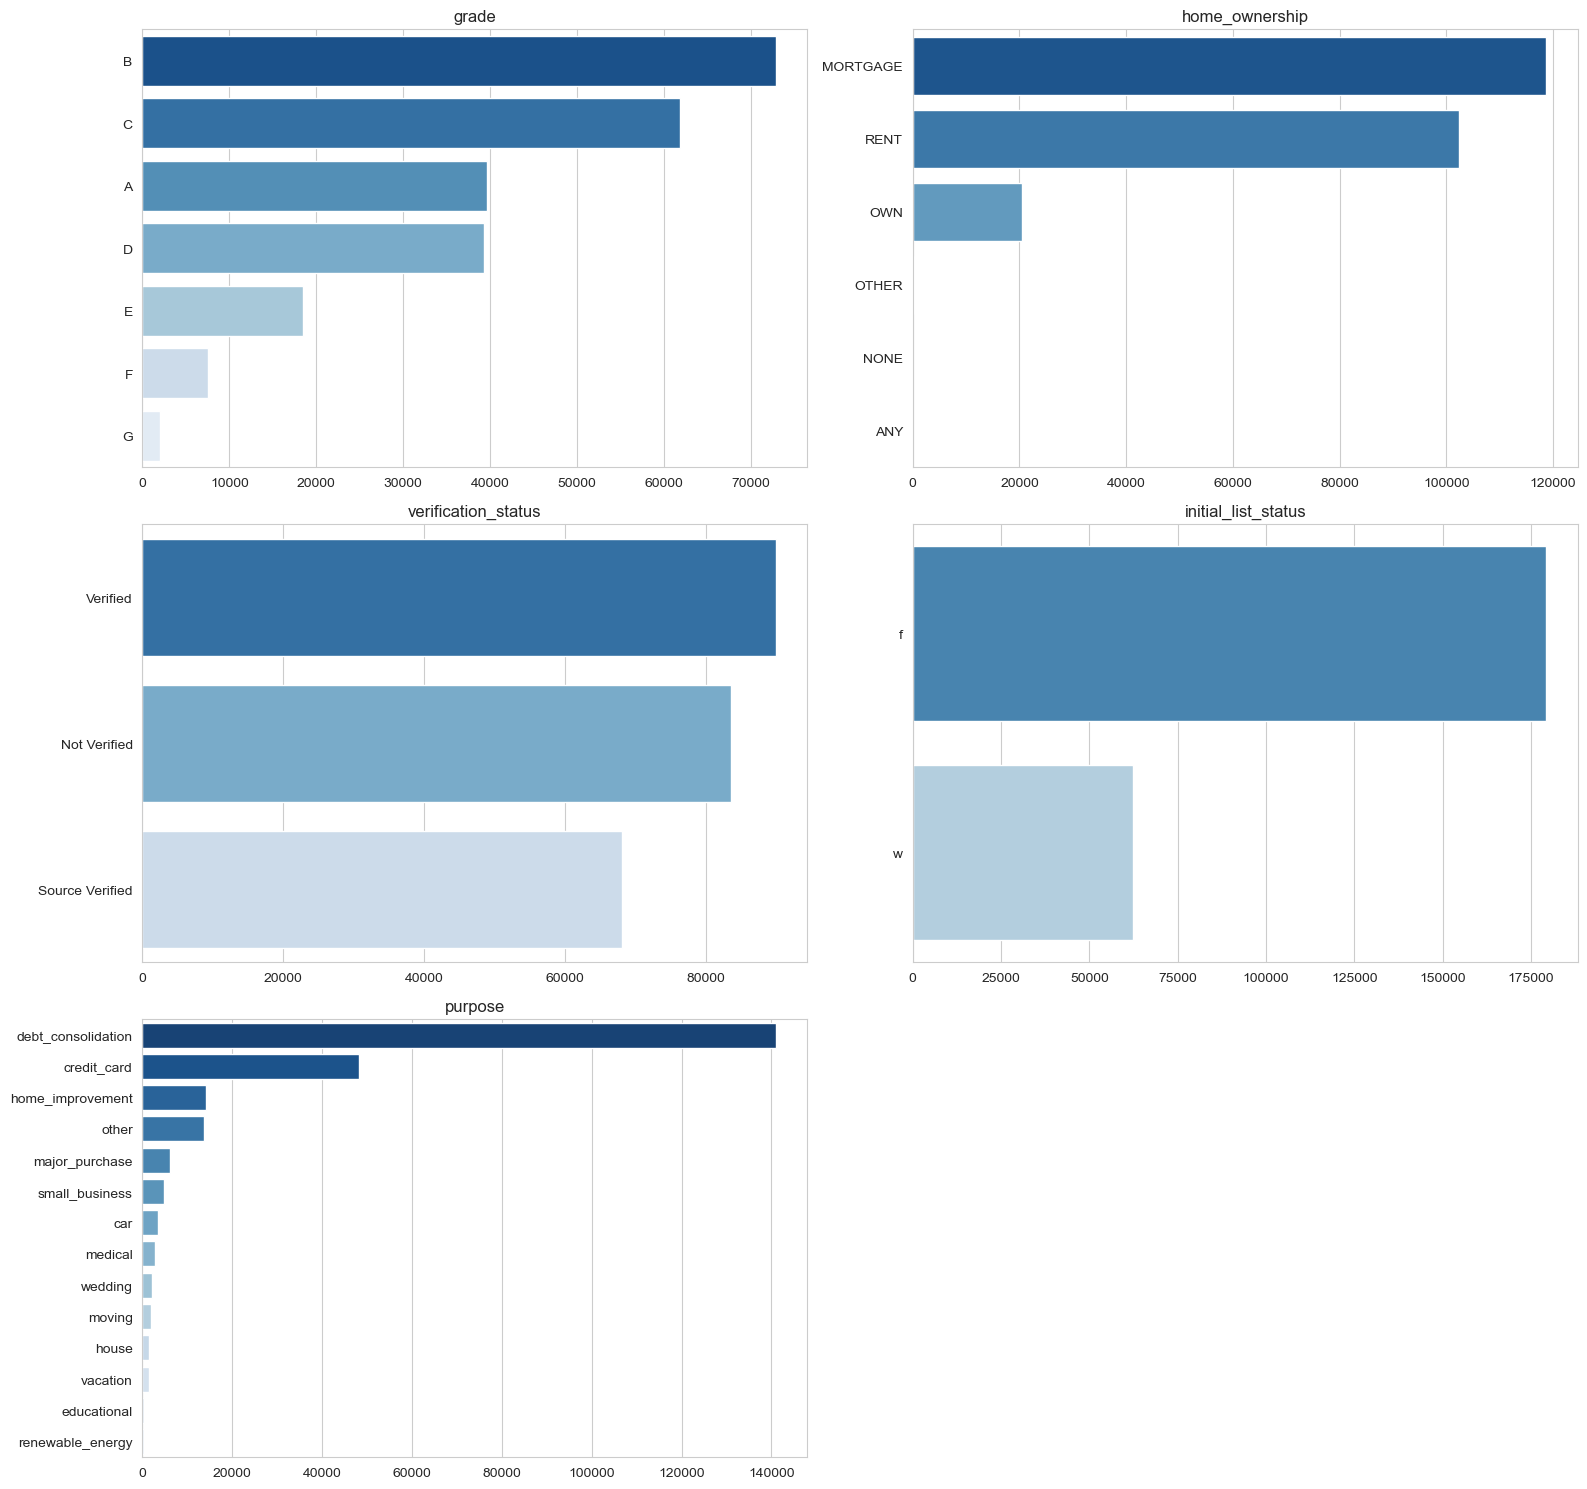

In [11]:
# Categóricas de baixa cardinalidade
baixa_card = ['grade', 'home_ownership', 'verification_status',
              'initial_list_status', 'purpose']

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for ax, col in zip(axes.flat, baixa_card):
    ordem = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=ordem, ax=ax, palette='Blues_r')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')
# remove o subplot vazio (são 5 variáveis em 6 espaços)
axes.flat[5].axis('off')
plt.tight_layout()
plt.show()

As variáveis categóricas revelam padrões relevantes. Em `grade`, predominam os graus intermediários (B e C), com os graus de maior risco (F e G) pouco representados. `home_ownership` concentra-se em MORTGAGE e RENT, enquanto as categorias OTHER, NONE e ANY têm participação ínfima e serão agrupadas na etapa de modelagem. Em `purpose`, destaca-se a forte predominância de `debt_consolidation` e `credit_card`, que juntas respondem pela maioria dos empréstimos; essa concentração reforça a relevância da restrição de diversificação por finalidade prevista na etapa de otimização. As demais variáveis (`verification_status`, `initial_list_status`) apresentam distribuição mais equilibrada.

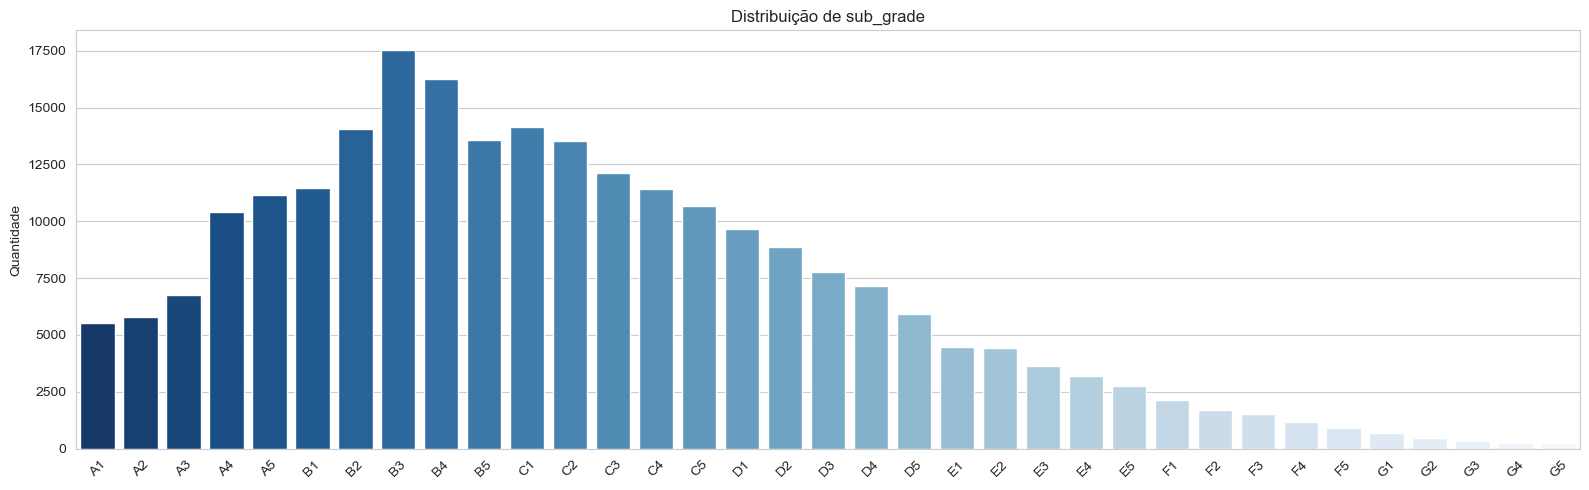

In [12]:
# sub_grade: ordem natural (A1 a G5), não por frequência
plt.figure(figsize=(16, 5))
ordem_sub = sorted(df['sub_grade'].unique())
sns.countplot(x='sub_grade', data=df, order=ordem_sub, palette='Blues_r')
plt.title('Distribuição de sub_grade')
plt.xlabel('')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

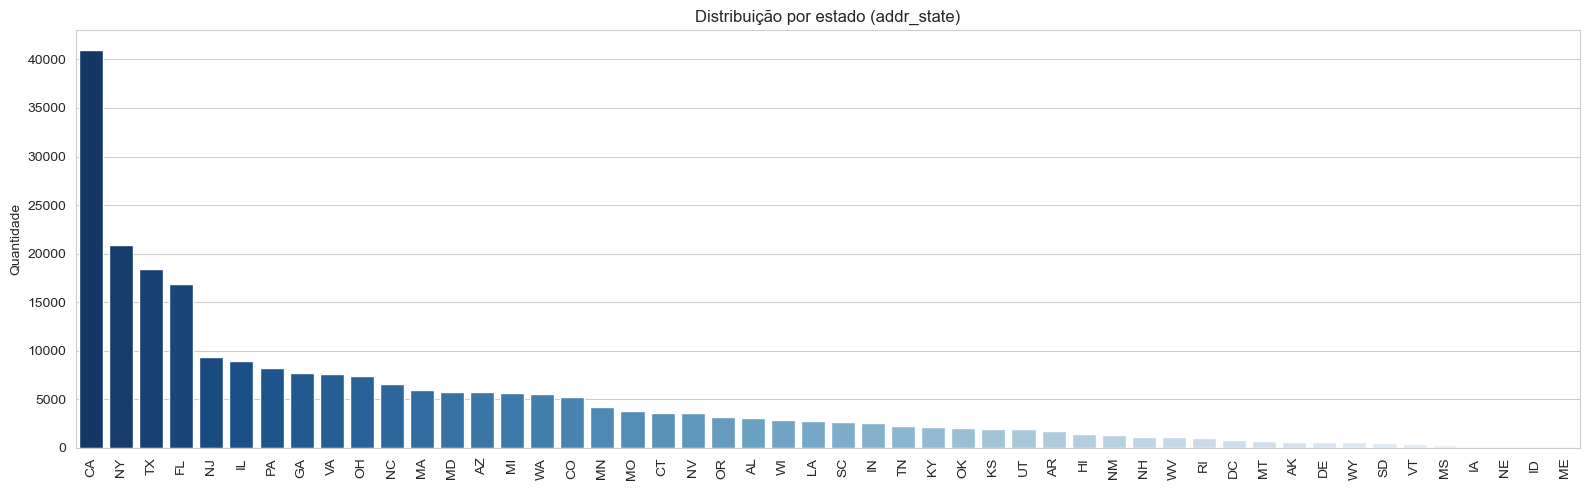

In [13]:
# addr_state: ordenado por frequência (são 50 estados)
plt.figure(figsize=(16, 5))
ordem_estado = df['addr_state'].value_counts().index
sns.countplot(x='addr_state', data=df, order=ordem_estado, palette='Blues_r')
plt.title('Distribuição por estado (addr_state)')
plt.xlabel('')
plt.ylabel('Quantidade')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

`sub_grade` apresenta comportamento ordinal consistente: a frequência cresce até os subgraus B3/B4 e decai progressivamente até G5, praticamente inexistente. Os subgraus de maior risco (E, F e G) possuem poucas observações, o que exigirá agrupamento de categorias na etapa de discretização. Em `addr_state`, observa-se forte concentração na Califórnia, que sozinha responde por cerca do dobro de empréstimos do segundo estado, seguida por Nova York, Texas e Flórida, com uma longa cauda de estados pouco representados. Essa concentração geográfica reforça a pertinência de uma eventual restrição de diversificação por região na etapa de otimização.

# 6. ANÁLISE DE CORRELAÇÃO

Analisamos a correlação entre as variáveis numéricas para identificar redundâncias. Pares fortemente correlacionados carregam informação semelhante e podem gerar multicolinearidade na regressão logística, sendo candidatos a simplificação na etapa de modelagem.

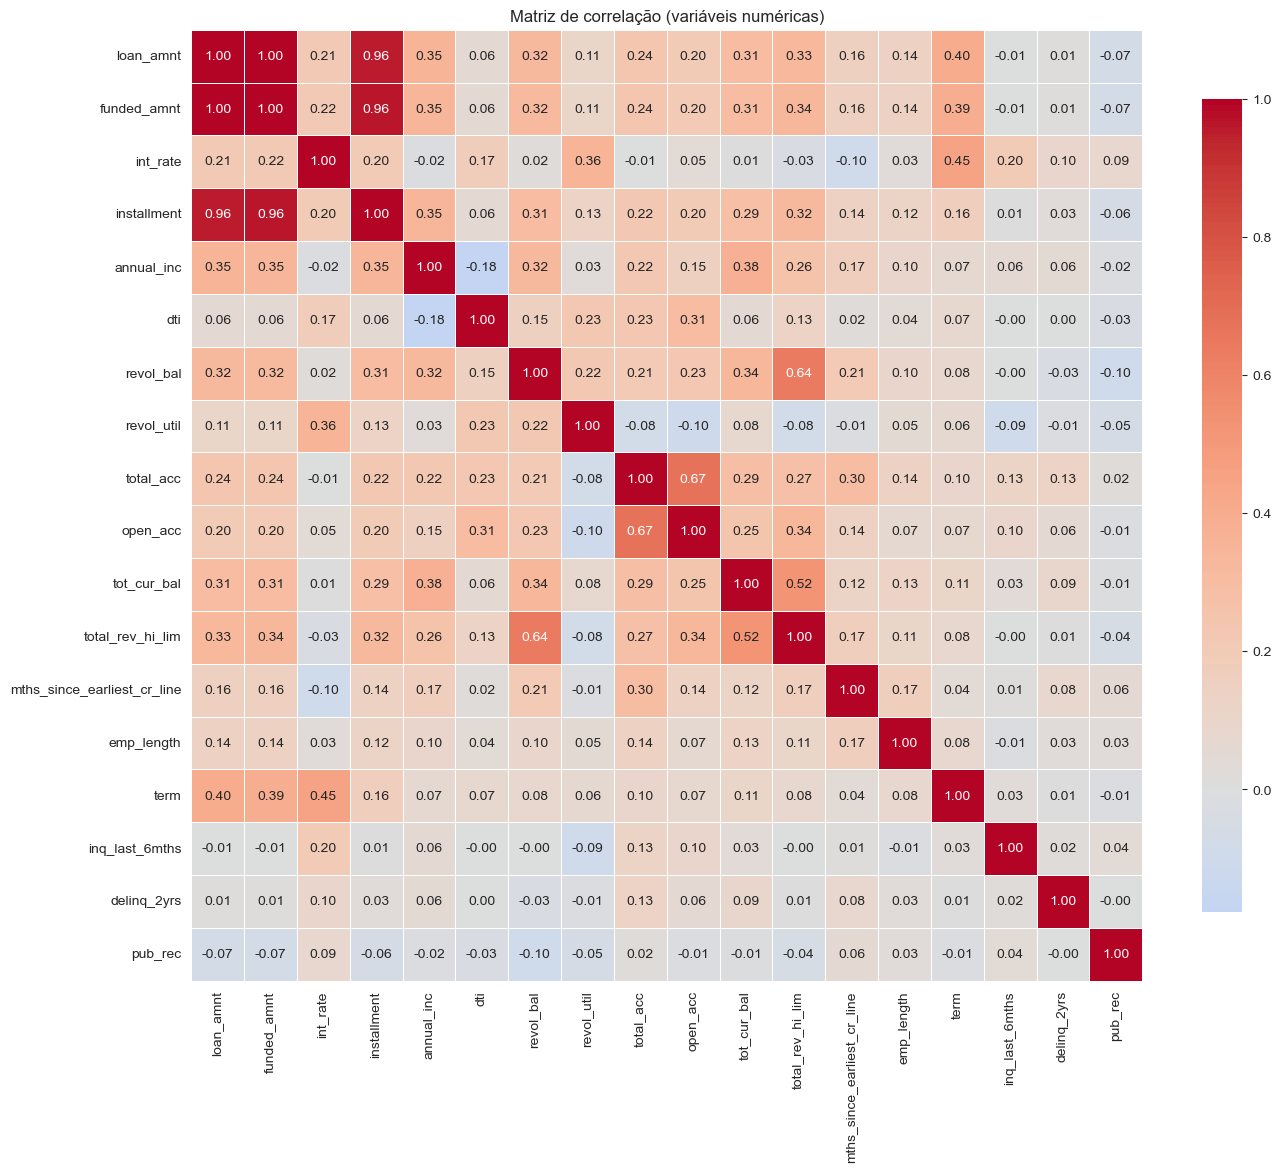

In [14]:
# Matriz de correlação das variáveis numéricas contínuas e discretas
num_corr = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc',
            'dti', 'revol_bal', 'revol_util', 'total_acc', 'open_acc',
            'tot_cur_bal', 'total_rev_hi_lim', 'mths_since_earliest_cr_line',
            'emp_length', 'term', 'inq_last_6mths', 'delinq_2yrs', 'pub_rec']

corr = df[num_corr].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlação (variáveis numéricas)')
plt.tight_layout()
plt.show()

In [15]:
# Pares de variáveis com correlação absoluta >= 0.7 (redundância a tratar)
corr_abs = df[num_corr].corr().abs()

# Mantém apenas o triângulo superior para não duplicar pares
triangulo = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

pares_redundantes = (
    triangulo.stack()
    .reset_index()
    .rename(columns={'level_0': 'variável 1', 'level_1': 'variável 2', 0: 'correlação'})
)
pares_redundantes = (
    pares_redundantes[pares_redundantes['correlação'] >= 0.7]
    .sort_values('correlação', ascending=False)
    .reset_index(drop=True)
)
pares_redundantes['correlação'] = pares_redundantes['correlação'].round(3)
pares_redundantes

,variável 1,variável 2,correlação
0,loan_amnt,funded_amnt,0.9970
1,funded_amnt,installment,0.9590
2,loan_amnt,installment,0.9550


Adotando um limiar de 0,7 para correlação absoluta, apenas três pares se destacam, todos envolvendo as variáveis `loan_amnt`, `funded_amnt` e `installment`. A redundância é, portanto, concentrada nesse trio. Como as três carregam essencialmente a mesma informação, será mantida apenas uma delas na etapa de modelagem, `loan_amnt`, descartando-se `funded_amnt` e `installment` para evitar multicolinearidade.

# 7. CONCLUSÃO

A análise exploratória permitiu compreender a estrutura dos dados e orientar as decisões da etapa de modelagem. Os principais achados foram:

- **Variável-alvo:** a base apresenta cerca de 21% de inadimplência, um desbalanceamento moderado que reflete apenas contratos com desfecho conhecido.
- **Redundância:** as variáveis `loan_amnt`, `funded_amnt` e `installment` são altamente correlacionadas (acima de 0,95); apenas `loan_amnt` será mantida.
- **Baixa variância:** `collections_12_mths_ex_med`, `acc_now_delinq` e `tot_coll_amt` são quase constantes (mais de 90% de zeros) e serão reavaliadas para remoção.
- **Alta cardinalidade:** `sub_grade` (35 categorias) e `addr_state` (50 categorias) exigirão agrupamento de categorias na discretização.
- **Categorias raras:** `home_ownership` possui categorias com participação ínfima (OTHER, NONE, ANY) que serão agrupadas.
- **Ausências informativas:** as variáveis com indicador de ausência criado no pré-processamento serão tratadas como categoria própria na discretização por WoE.

Essas observações serão aplicadas no notebook seguinte (`03_Probabilidade_Default`), que realiza o split out-of-time, a transformação das variáveis por Weight of Evidence e a estimação do modelo de probabilidade de default.